<a href="https://colab.research.google.com/github/pach28/Binary-Prediction-with-a-Rainfall-Dataset/blob/main/EDA_y_Modelos_Iniciales_BPRD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

pt1

#instalamos librerias necesarias e iniciamos sesion de kaggle para acceder a la data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_style('whitegrid')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
import os

# Download the competition dataset
playground_series_s5e2_path = kagglehub.competition_download('playground-series-s5e3')

# Extract the directory name from the downloaded path
dataset_dir = os.path.splitext(playground_series_s5e2_path)[0]

# Construct the correct paths to the train.csv and test.csv files
train_csv_path = os.path.join(dataset_dir, 'train.csv')
test_csv_path = os.path.join(dataset_dir, 'test.csv')
sample_submission_csv_path = os.path.join(dataset_dir, 'sample_submission.csv')
# Read the CSV files using the correct paths
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
sample_submission_df = pd.read_csv(sample_submission_csv_path)

In [ ]:
train_df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


#EDA

In [ ]:
train_df.describe()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
count,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000,2190.000000
mean,1094.500000,179.948402,1013.602146,26.365799,23.953059,22.170091,20.454566,82.036530,75.721918,3.744429,104.863151,21.804703,0.753425
std,632.342866,105.203592,5.655366,5.654330,5.222410,5.059120,5.288406,7.800654,18.026498,3.626327,80.002416,9.898659,0.431116
min,0.000000,1.000000,999.000000,10.400000,7.400000,4.000000,-0.300000,39.000000,2.000000,0.000000,10.000000,4.400000,0.000000
25%,547.250000,89.000000,1008.600000,21.300000,19.300000,17.700000,16.800000,77.000000,69.000000,0.400000,40.000000,14.125000,1.000000
50%,1094.500000,178.500000,1013.000000,27.800000,25.500000,23.850000,22.150000,82.000000,83.000000,2.400000,70.000000,20.500000,1.000000
75%,1641.750000,270.000000,1017.775000,31.200000,28.400000,26.400000,25.000000,88.000000,88.000000,6.800000,200.000000,27.900000,1.000000
max,2189.000000,365.000000,1034.600000,36.000000,31.500000,29.800000,26.700000,98.000000,100.000000,12.100000,300.000000,59.500000,1.000000


In [ ]:
#hay NaN
train_df.isna().sum()

,0
id,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
sunshine,0


<Axes: >

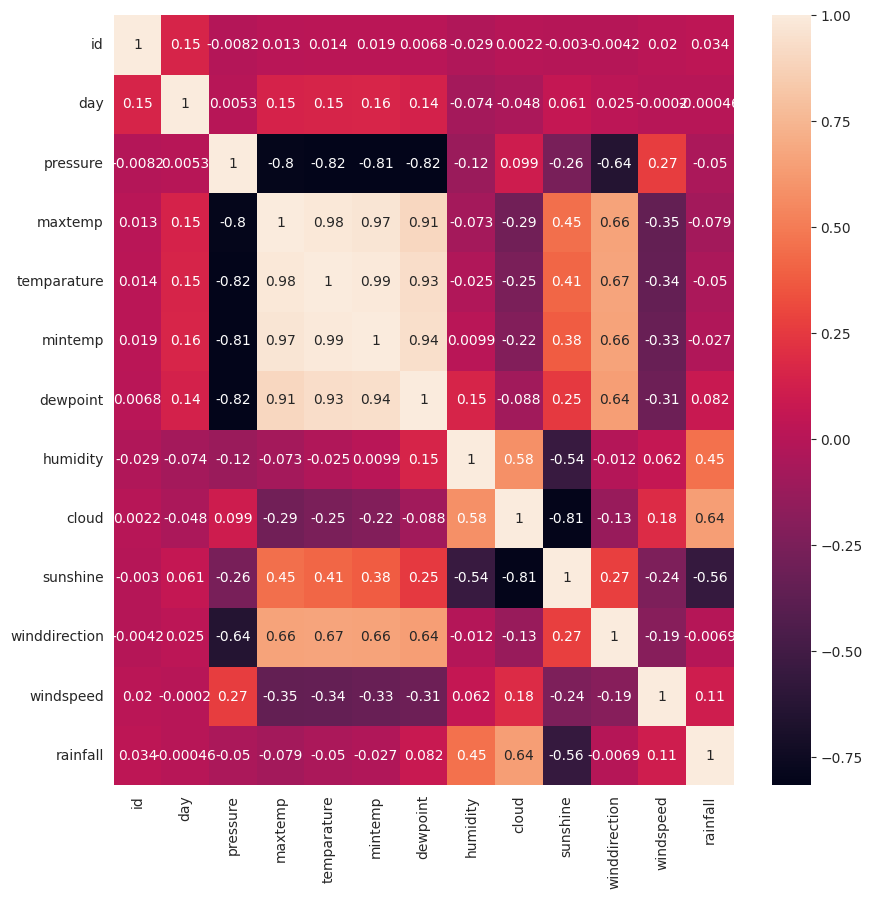

In [ ]:
#heatmap de train_df
plt.figure(figsize=(10,10))
sns.heatmap(train_df.corr(),annot=True)

In [ ]:
import seaborn as sns

def graficar_matriz_correlacion_retardos(datos, columna_lluvia, retardos=10):
  """Grafica la matriz de correlación de retardos."""
  retardos_datos = [datos[columna_lluvia].shift(i) for i in range(retardos + 1)]
  retardos_datos = pd.concat(retardos_datos, axis=1).dropna()
  retardos_datos.columns = [f'Retardo {i}' for i in range(retardos + 1)]
  plt.figure(figsize=(10, 8))
  sns.heatmap(retardos_datos.corr(), annot=True, cmap='coolwarm')
  plt.title('Matriz de Correlación de Retardos')
  plt.show()
  # Ejemplo de uso
  # graficar_matriz_correlacion_retardos(df, 'cantidad_lluvia')

como primera busqueda de correlaciones estaremos buscando la relacion de lluvia con 10 dias anteriores, normalmente las lluvias se dan en dias concecutivos en ciertas temporadas, tambien buscaremos estacionalidad de las lluvias y otros patrones que nos ayuden con las probabilidades

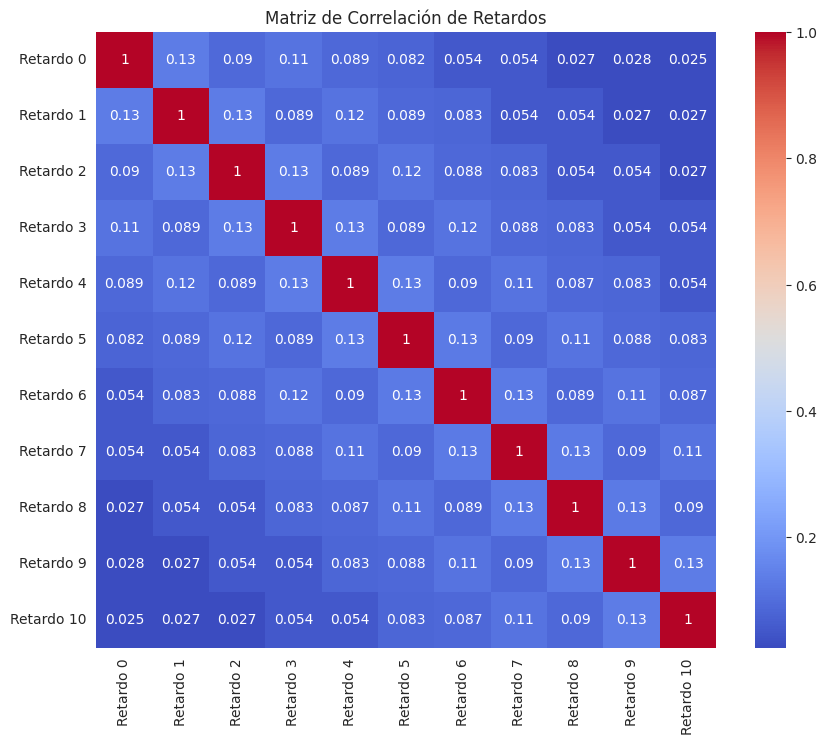

In [ ]:
graficar_matriz_correlacion_retardos(train_df, 'rainfall')

veremos si los datos de train y test tienen distribuciones similares

In [ ]:
comp_train = train_df.drop('id',axis=1)
comp_test = test_df.drop('id',axis=1)
#agregar 1 a todos los comp_test y 0 a todos los comp_train
comp_test['origen'] = 1
comp_train['origen'] = 0
comp_train = comp_train.drop('rainfall',axis=1)
comp_total = pd.concat([comp_train,comp_test],axis=0)

In [ ]:
comp_total.drop('day',axis=1,inplace=True)

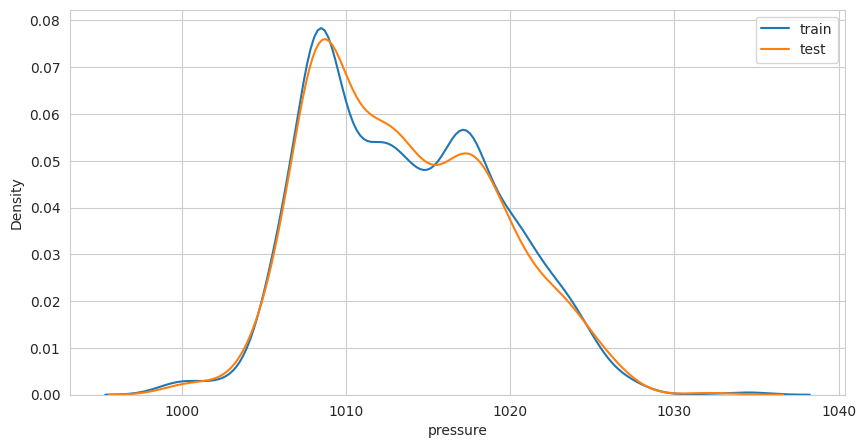

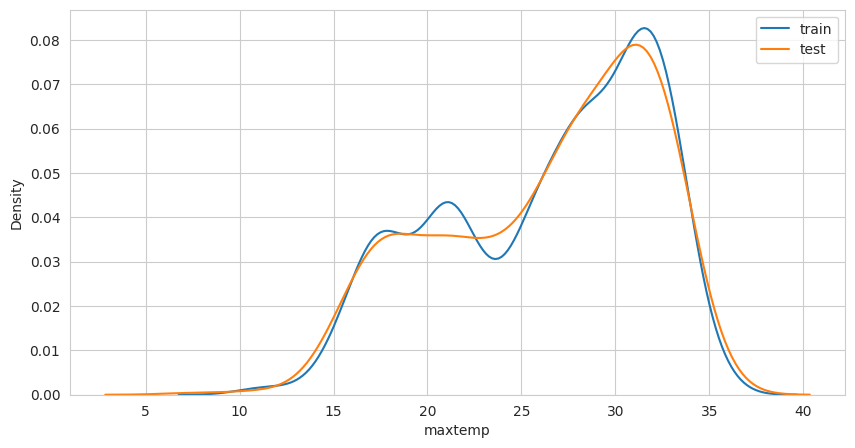

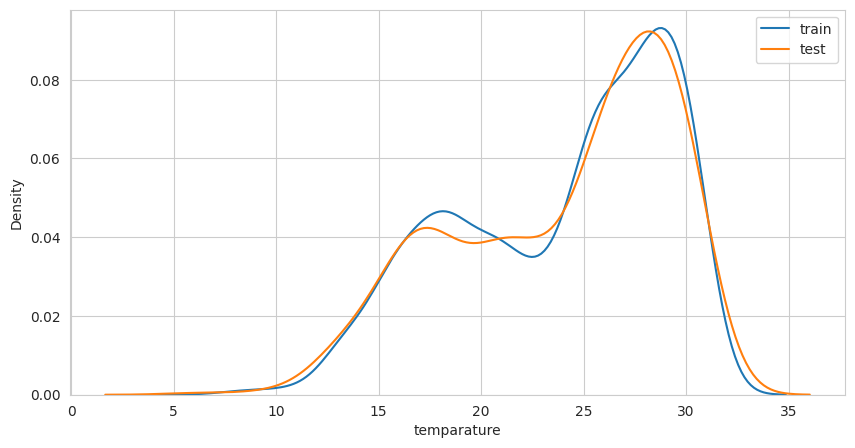

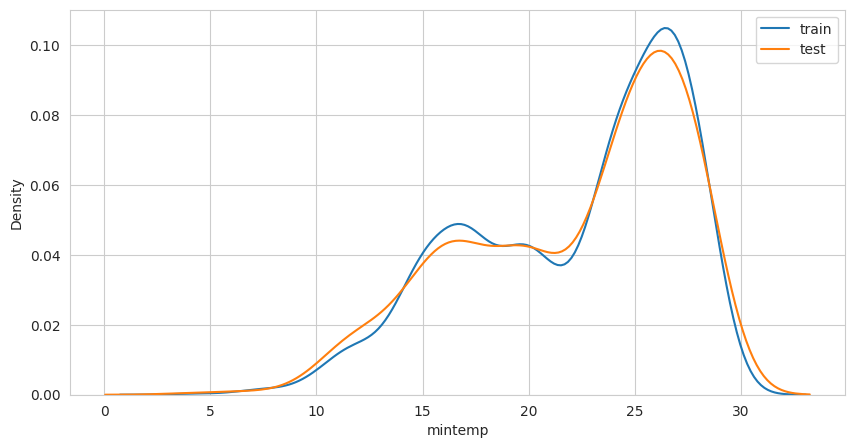

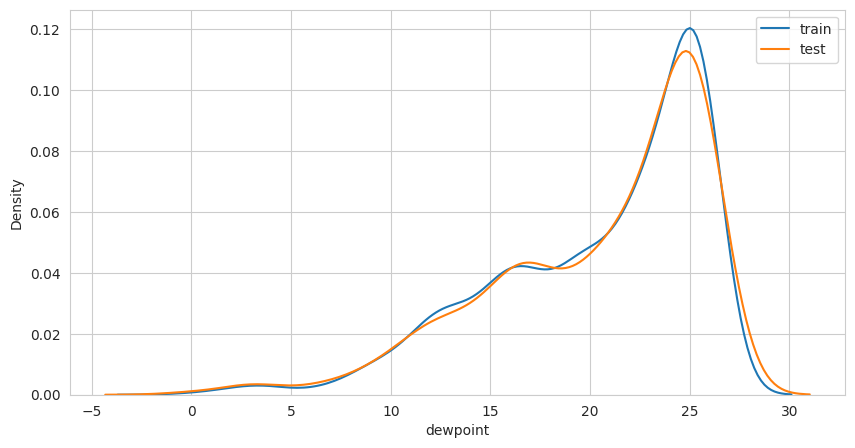

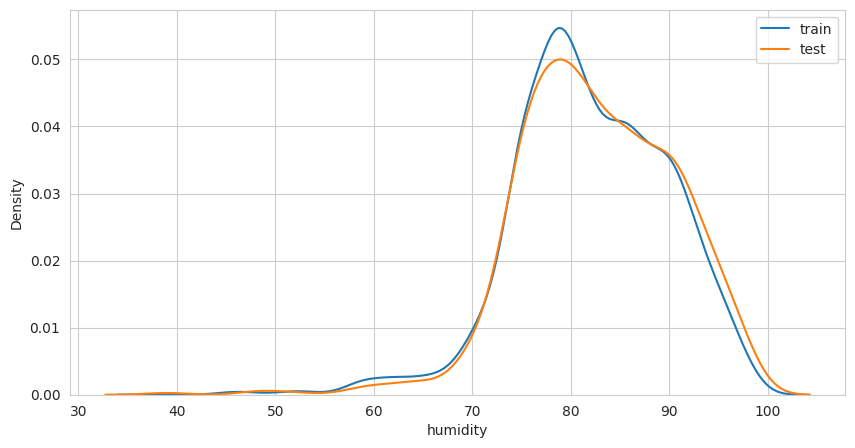

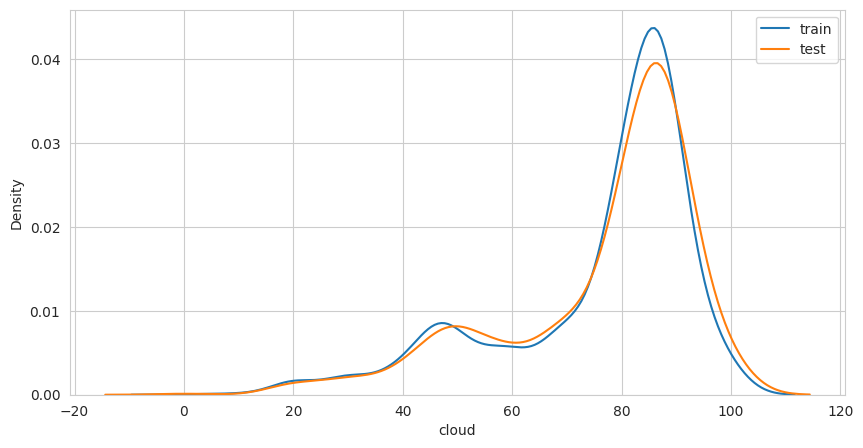

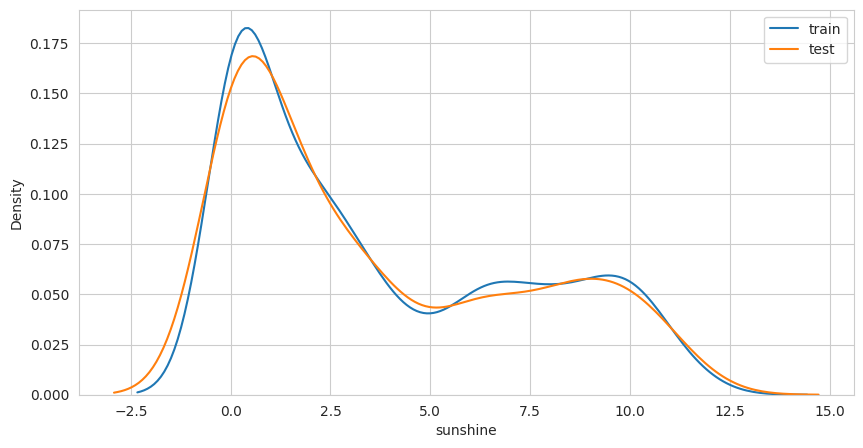

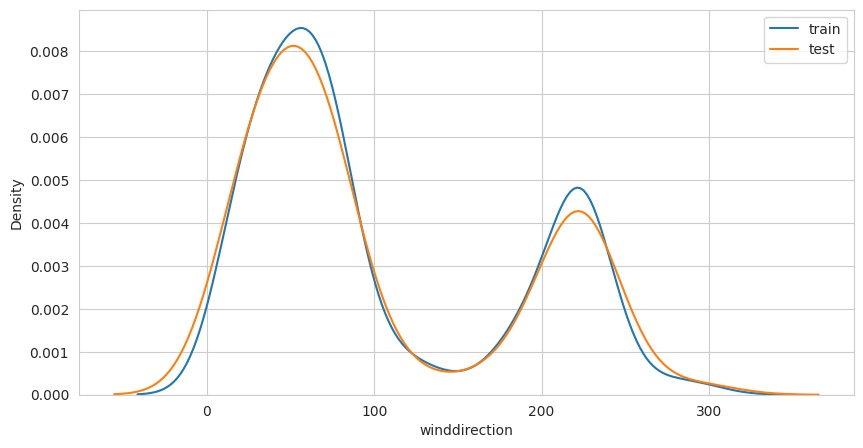

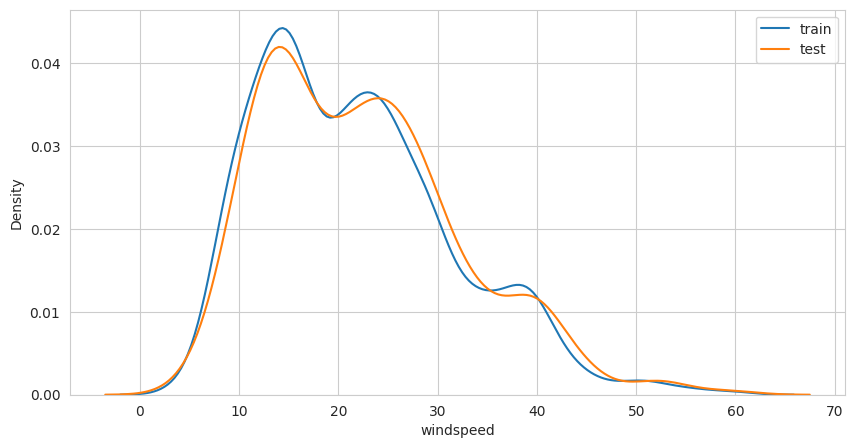

In [ ]:
#graficar cada columna diferenciando por color en origen
for col in comp_total.columns:
  if col != 'origen':
    plt.figure(figsize=(10,5))
    sns.kdeplot(comp_total[comp_total['origen']==0][col],label='train')
    sns.kdeplot(comp_total[comp_total['origen']==1][col],label='test')
    plt.legend()

In [ ]:
#haremos un random forest para identificar si se puede diferenciar entre test y train
from sklearn.ensemble import RandomForestClassifier
#kfolds
from sklearn.model_selection import KFold
#Auc
from sklearn.metrics import roc_auc_score

X = comp_total.drop('origen',axis=1)
y = comp_total['origen']

kf = KFold(n_splits=5, shuffle=True, random_state=28)
modelcomp = RandomForestClassifier(n_estimators=200)
aucs = []
n = 1
for train_index, test_index in kf.split(X):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  modelcomp.fit(X_train, y_train)
  y_pred = modelcomp.predict(X_test)
  auc = roc_auc_score(y_test, y_pred)
  aucs.append(auc)
  print(f"AUC del fold {n}: {auc}")
  n += 1

AUC del fold 1: 0.48875727447156025
AUC del fold 2: 0.49622990685652235
AUC del fold 3: 0.49875262605042014
AUC del fold 4: 0.5057077625570776
AUC del fold 5: 0.49370280881908785


con esto podemos estar un poco mas seguros que los datos de train y test tienen variables similares, de forma que aplicar modelos entrenados con todo train pordrian ser de utilidad sin llegar al sobre ajuste

#corregimos el orden de los dias de los datos, debido a que hay discrepancia en el orden de 1 al 365 en los 6 años de datos

<Axes: xlabel='day', ylabel='Count'>

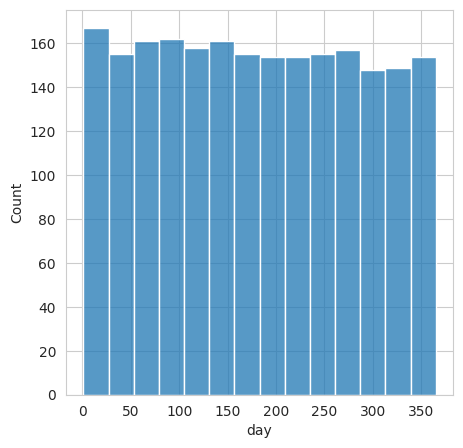

In [ ]:
#graficar los day de train histograma
plt.figure(figsize=(5,5))
sns.histplot(train_df['day'])

tenemos la informacion de 6 años donde los valores de dias van del 1 al 365 en todos los casos, depreciamos los dias de años bisiestos, aunque hay dias mal regristados, arreglaremos eso de manera sencilla creando una serie de 1 al 365, 6 veces y pegandola al df

In [ ]:
#crear una columna llamada day_1 del 1 al 365, 6 veces
day_1 = pd.DataFrame(columns=['day_1'])
for i in range(6):
  rango = np.arange(1,366)
  day_1 = pd.concat([day_1,pd.DataFrame(rango,columns=['day_1'])], ignore_index=True)
#pegar day_1 al train_df
train_df = pd.concat([train_df,day_1.reset_index(drop=True)],axis=1) # Reset index of day_1 before concatenating

<Axes: xlabel='day_1', ylabel='Count'>

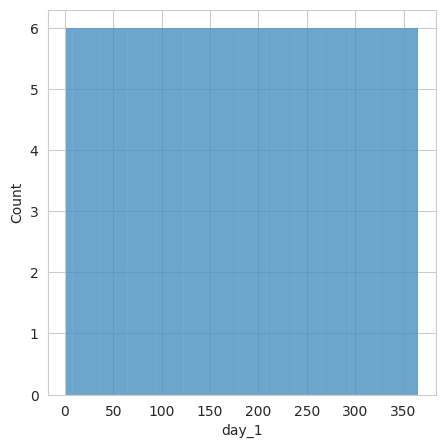

In [ ]:
#graficar los day de train histograma
plt.figure(figsize=(5,5))
sns.histplot(train_df['day_1'],bins=365)

una vez resuelto el tema de los dias en desorden agregaremos columnas de mes y estacion del año

#Creacion de funcion para identificar las estaciones del año

In [ ]:
def crear_columnas_estaciones(df, columna_dia):
  """Crea columnas binarias para las estaciones del año."""

  df['Primavera'] = ((df[columna_dia] >= 80) & (df[columna_dia] <= 172)).astype(int)
  df['Verano'] = ((df[columna_dia] >= 173) & (df[columna_dia] <= 265)).astype(int)
  df['Otono'] = ((df[columna_dia] >= 266) & (df[columna_dia] <= 355)).astype(int)
  df['Invierno'] = (((df[columna_dia] >= 356) & (df[columna_dia] <= 365)) | ((df[columna_dia] >= 1) & (df[columna_dia] <= 79))).astype(int)
  #return df

In [ ]:
crear_columnas_estaciones(train_df,'day_1')

In [ ]:
train_df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,day_1,Primavera,Verano,Otono,Invierno
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,1,0,0,0,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,2,0,0,0,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1,3,0,0,0,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,4,0,0,0,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0,5,0,0,0,1


observamos que en primavera hay mas lluvias y al ultimo en verano

In [ ]:
#cuantos rainfall hay en Primavera, Verano, Otono, Invierno
#cuando hay 1 en rainfall y primavera,...
print(len(train_df[(train_df['Primavera']==1) & (train_df['rainfall']==1)]))
print(len(train_df[(train_df['Verano']==1) & (train_df['rainfall']==1)]))
print(len(train_df[(train_df['Otono']==1) & (train_df['rainfall']==1)]))
print(len(train_df[(train_df['Invierno']==1) & (train_df['rainfall']==1)]))

455
386
411
398


ploteamos cada año para identificar patrones de lluvia o estacionalidad en las lluvias, igual hacemos un promedio de dias por año que llovió

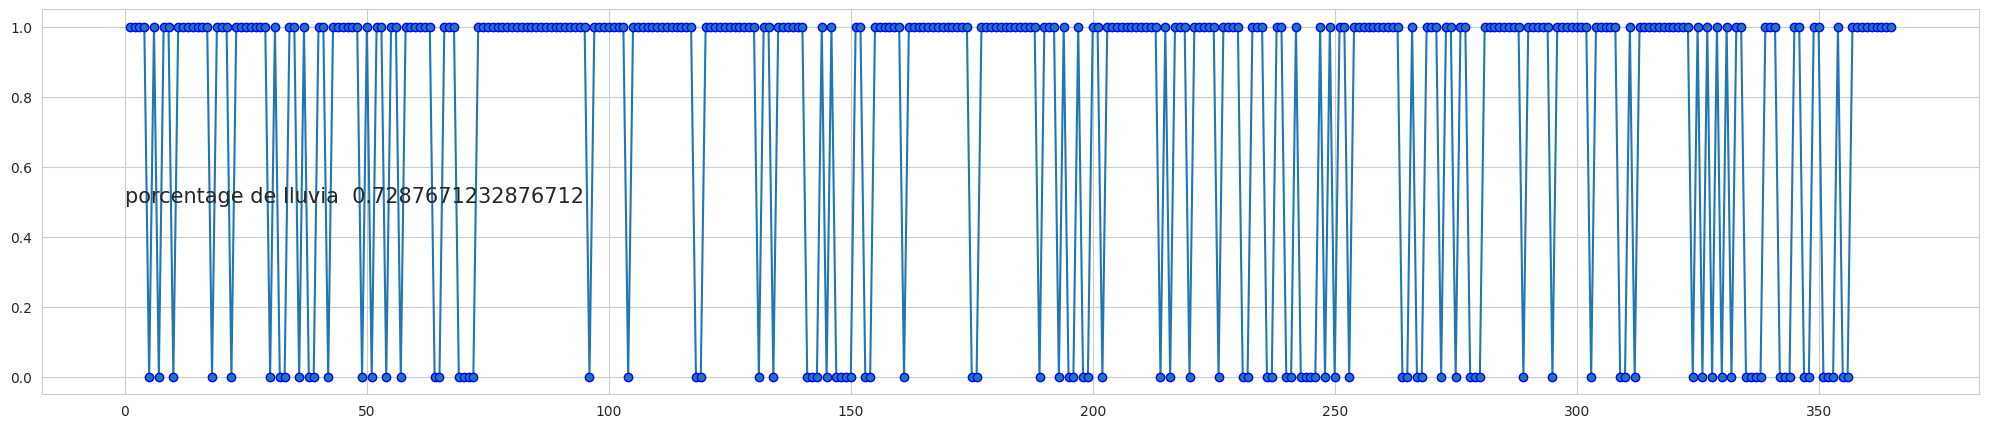

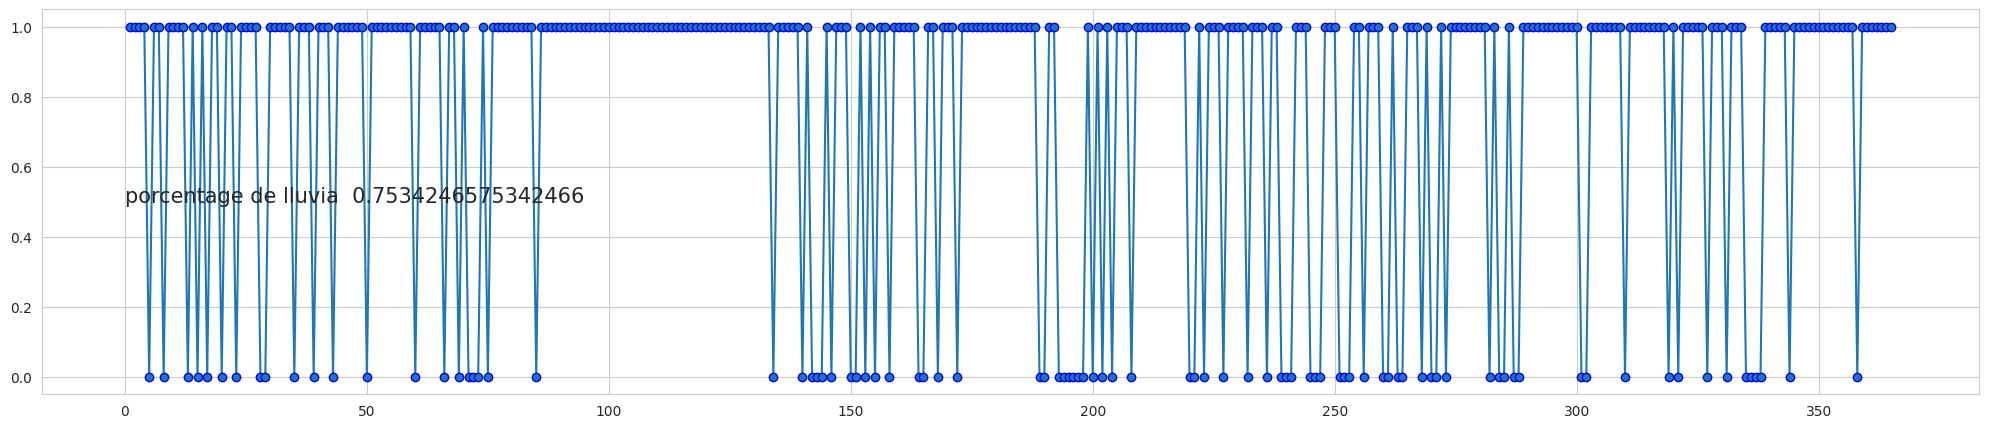

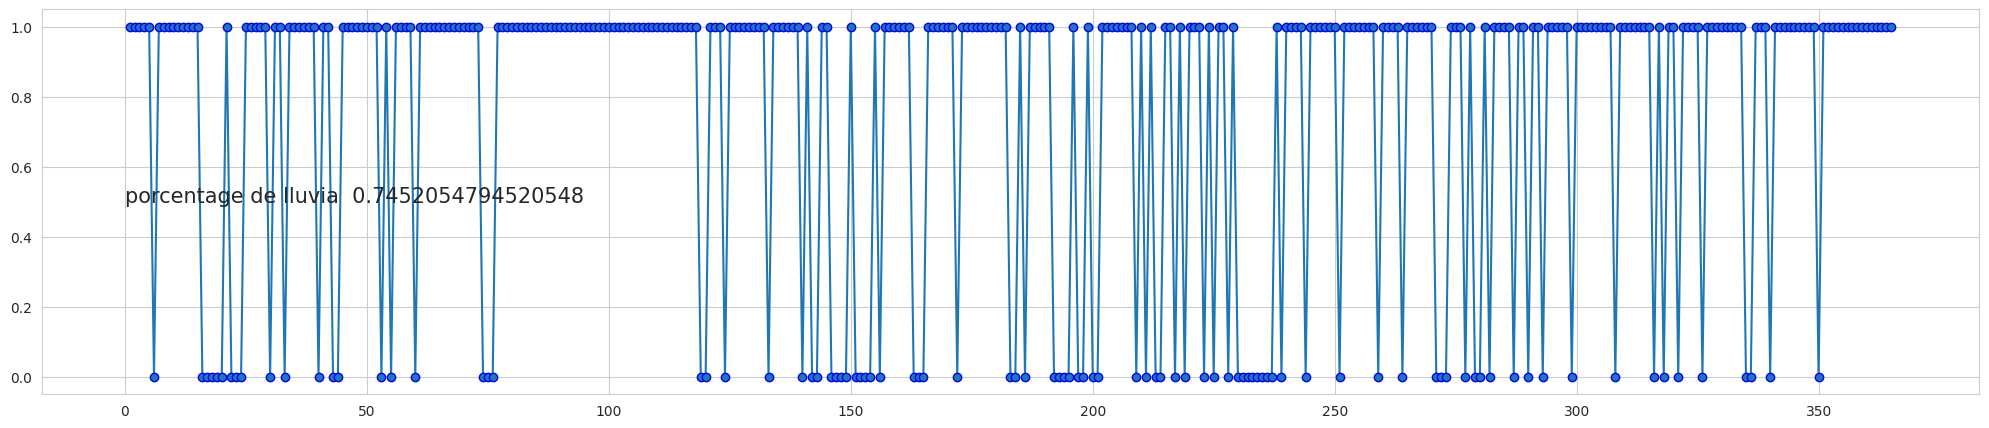

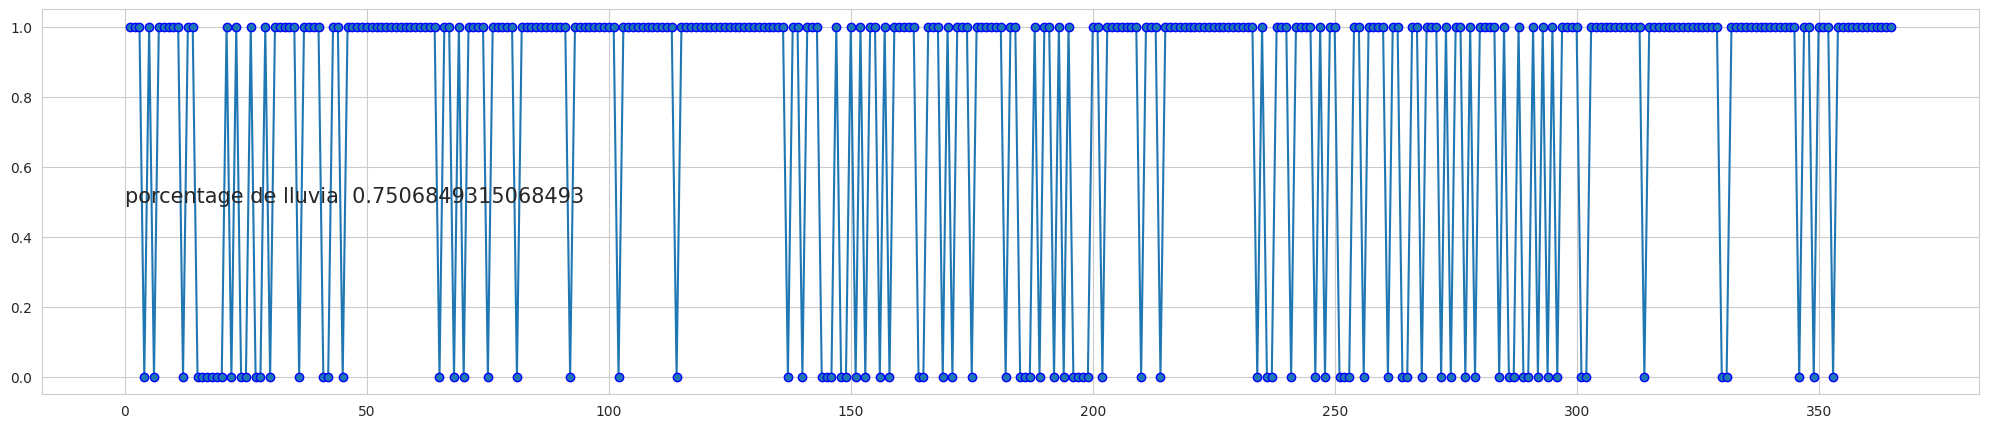

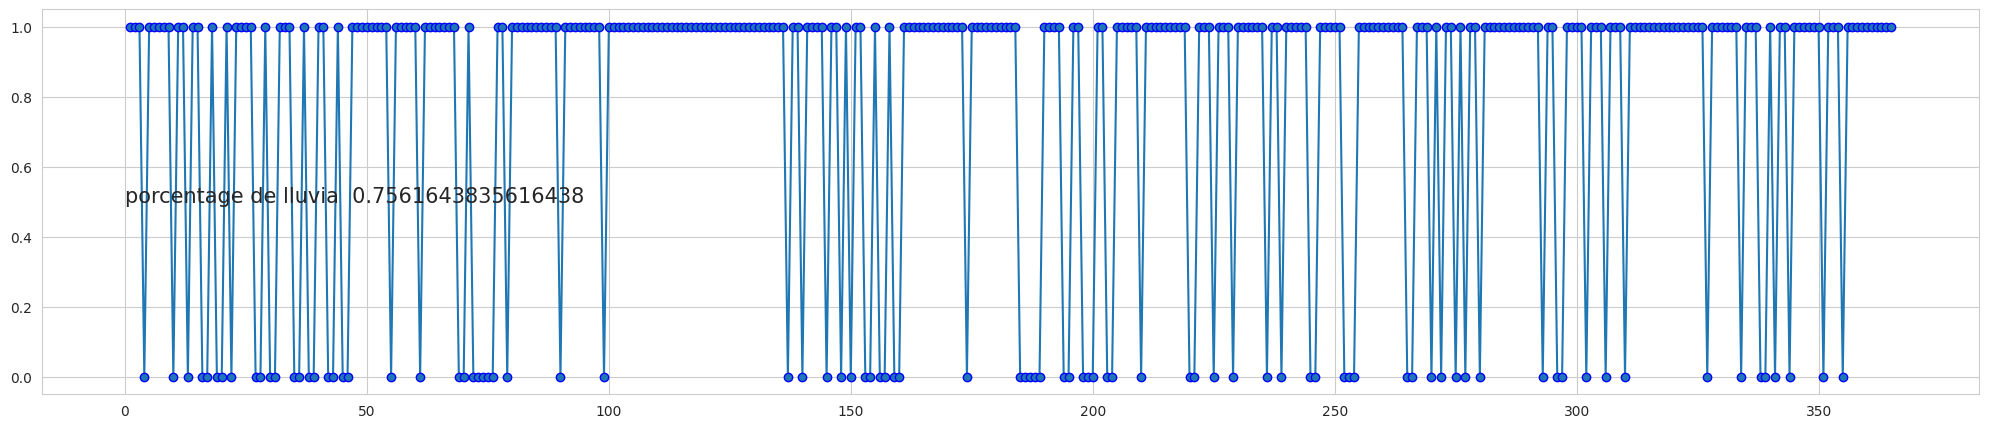

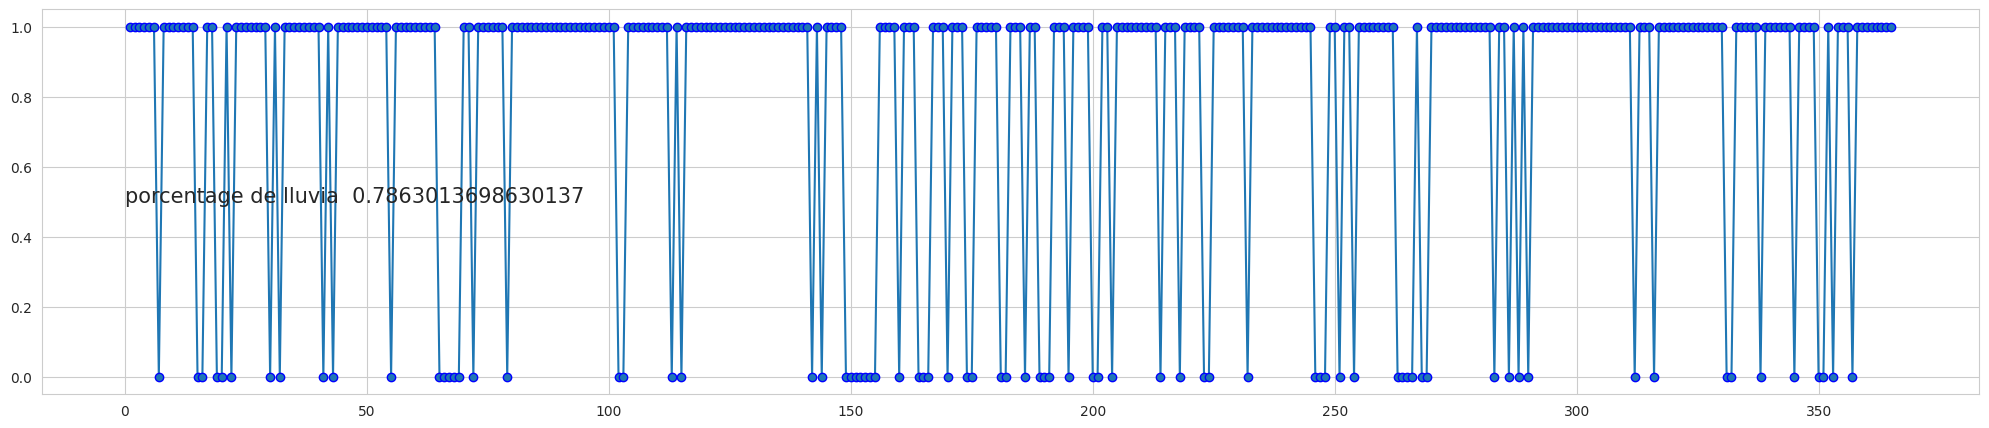

In [ ]:
#ahora un plot para cada año
inicio = 0
fin = 365
for i in range(6):
  plt.figure(figsize=(25,5))
  plt.plot(train_df.iloc[inicio:fin,:]['day_1'],train_df.iloc[inicio:fin,:]['rainfall'],marker='o',markeredgecolor='b')
  porcentage = train_df.iloc[inicio:fin,:]['rainfall'].sum()/365
  #agregar un comentario el porcentage de 1 de rainfalls
  plt.text(0,.5,f'porcentage de lluvia  {porcentage}',fontsize=15)
  inicio = fin
  fin = fin + 365

#creamos funcion que nos diga el dia y mes de cada registro

In [ ]:
#crearemos una columna que vaya por dias del mes
def crear_columnas_dia_mes(df, columna_dia_anio):
    """
    Crea columnas 'dia_del_mes' y 'mes' a partir de una columna de días del año.

    Args:
        df (pd.DataFrame): El DataFrame que contiene la columna de días del año.
        columna_dia_anio (str): El nombre de la columna que contiene los días del año (1-365).

    Returns:
        pd.DataFrame: El DataFrame con las nuevas columnas 'dia_del_mes' y 'mes'.
    """

    dias_acumulados = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]  # Días acumulados al inicio de cada mes

    meses = []
    dias_del_mes = []

    for dia_anio in df[columna_dia_anio]:
        for mes_num in range(1, 13):
            if dia_anio <= dias_acumulados[mes_num]:
                meses.append(mes_num)
                dias_del_mes.append(dia_anio - dias_acumulados[mes_num - 1])
                break

    df['mes'] = meses
    df['dia_del_mes'] = dias_del_mes

In [ ]:
crear_columnas_dia_mes(train_df,'day_1')

In [ ]:
train_df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall,day_1,Primavera,Verano,Otono,Invierno,mes,dia_del_mes
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1,1,0,0,0,1,1,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1,2,0,0,0,1,1,2
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1,3,0,0,0,1,1,3
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1,4,0,0,0,1,1,4
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0,5,0,0,0,1,1,5


asi podemos observar en que meses llueve mas

In [ ]:
#contar los rainfall por cada unique de mes
for mes in train_df['mes'].unique():
  print(f'en el mes {mes} llueve {len(train_df[(train_df["mes"]==mes) & (train_df["rainfall"]==1)])/6} dias en promedio')

en el mes 1 llueve 21.166666666666668 dias en promedio
en el mes 2 llueve 21.833333333333332 dias en promedio
en el mes 3 llueve 24.333333333333332 dias en promedio
en el mes 4 llueve 27.666666666666668 dias en promedio
en el mes 5 llueve 23.333333333333332 dias en promedio
en el mes 6 llueve 22.166666666666668 dias en promedio
en el mes 7 llueve 19.833333333333332 dias en promedio
en el mes 8 llueve 22.333333333333332 dias en promedio
en el mes 9 llueve 19.333333333333332 dias en promedio
en el mes 10 llueve 23.333333333333332 dias en promedio
en el mes 11 llueve 25.166666666666668 dias en promedio
en el mes 12 llueve 24.5 dias en promedio


In [ ]:
#guardar los promedios por dia
promedios = pd.DataFrame(columns=['dia','promedio'])
for dia in train_df['day_1'].unique():
  prom = len(train_df[(train_df["day_1"]==dia) & (train_df["rainfall"]==1)])/6
  promedios = pd.concat([promedios,pd.DataFrame({'dia':[dia],'promedio':[prom]})],ignore_index=True)

In [ ]:
#agregar promedios a train_df
train_df = pd.merge(train_df,promedios,left_on='day_1',right_on='dia',how='left')

In [ ]:
train_df.drop('dia',axis=1,inplace=True)

por ultimo haremos un pair plot de el nuevo df train con dabl

In [ ]:
!pip install dabl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 9.8 MB/s eta 0:00:00


In [ ]:
train_df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,...,windspeed,rainfall,day_1,Primavera,Verano,Otono,Invierno,mes,dia_del_mes,promedio
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,...,17.2,1,1,0,0,0,1,1,1,1.000000
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,...,21.9,1,2,0,0,0,1,1,2,1.000000
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,...,18.1,1,3,0,0,0,1,1,3,1.000000
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,...,35.6,1,4,0,0,0,1,1,4,0.666667
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,...,24.8,0,5,0,0,0,1,1,5,0.666667


In [ ]:
#transformamos variables para ver el comportamiento en dabl
train_df_copy = train_df.copy()
train_df_copy['pressure_log'] = np.log(train_df_copy['pressure'])
#estandarizamos humidity, cloud, winddirection
train_df_copy['humidity_std'] = (train_df_copy['humidity']-train_df_copy['humidity'].mean())/train_df_copy['humidity'].std()
train_df_copy['cloud_std'] = (train_df_copy['cloud']-train_df_copy['cloud'].mean())/train_df_copy['cloud'].std()
train_df_copy['winddirection_std'] = (train_df_copy['winddirection']-train_df_copy['winddirection'].mean())/train_df_copy['winddirection'].std()

In [ ]:
train_df_copy.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,...,Verano,Otono,Invierno,mes,dia_del_mes,promedio,pressure_log,humidity_std,cloud_std,winddirection_std
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,...,0,0,1,1,1,1.000000,6.925006,0.636289,0.681113,-0.560772
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,...,0,0,1,1,2,1.000000,6.927068,1.661844,0.847535,-0.685769
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,...,0,0,1,1,3,1.000000,6.931569,-0.902044,-1.593317,-0.435776
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,...,0,0,1,1,4,0.666667,6.921066,1.661844,1.069430,-0.560772
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,...,0,0,1,1,5,0.666667,6.929321,-3.850515,-1.704264,-0.810765


<Axes: >

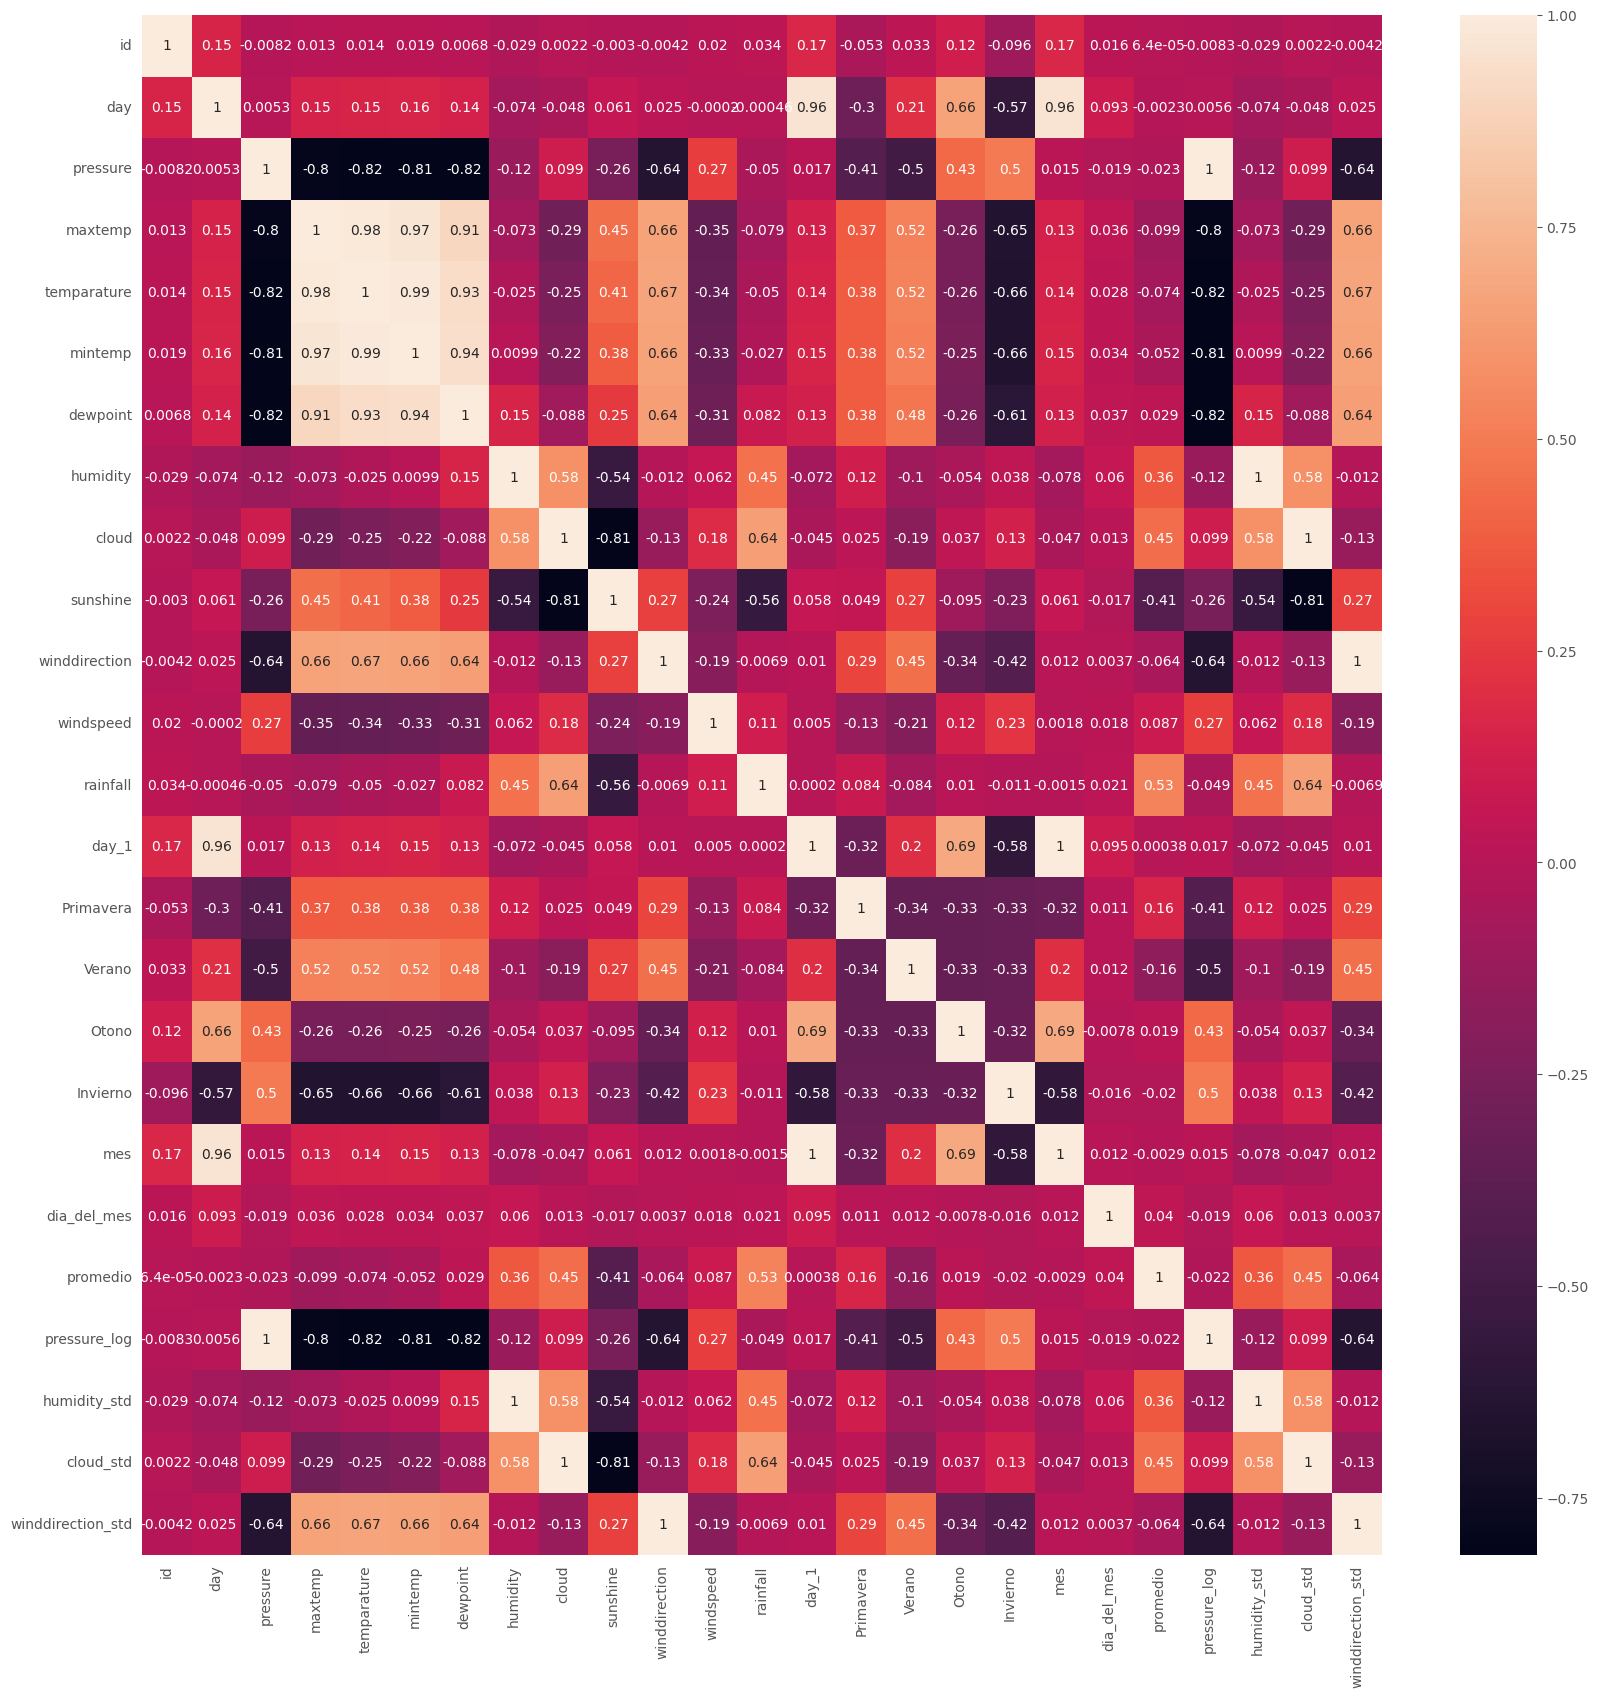

In [ ]:
#heatmap de train_df_copy
plt.figure(figsize=(20,20))
sns.heatmap(train_df_copy.corr(),annot=True)

Target looks like classification
Linear Discriminant Analysis training set score: 0.820


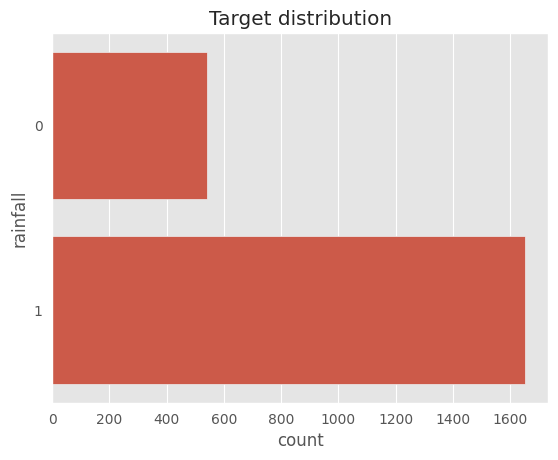

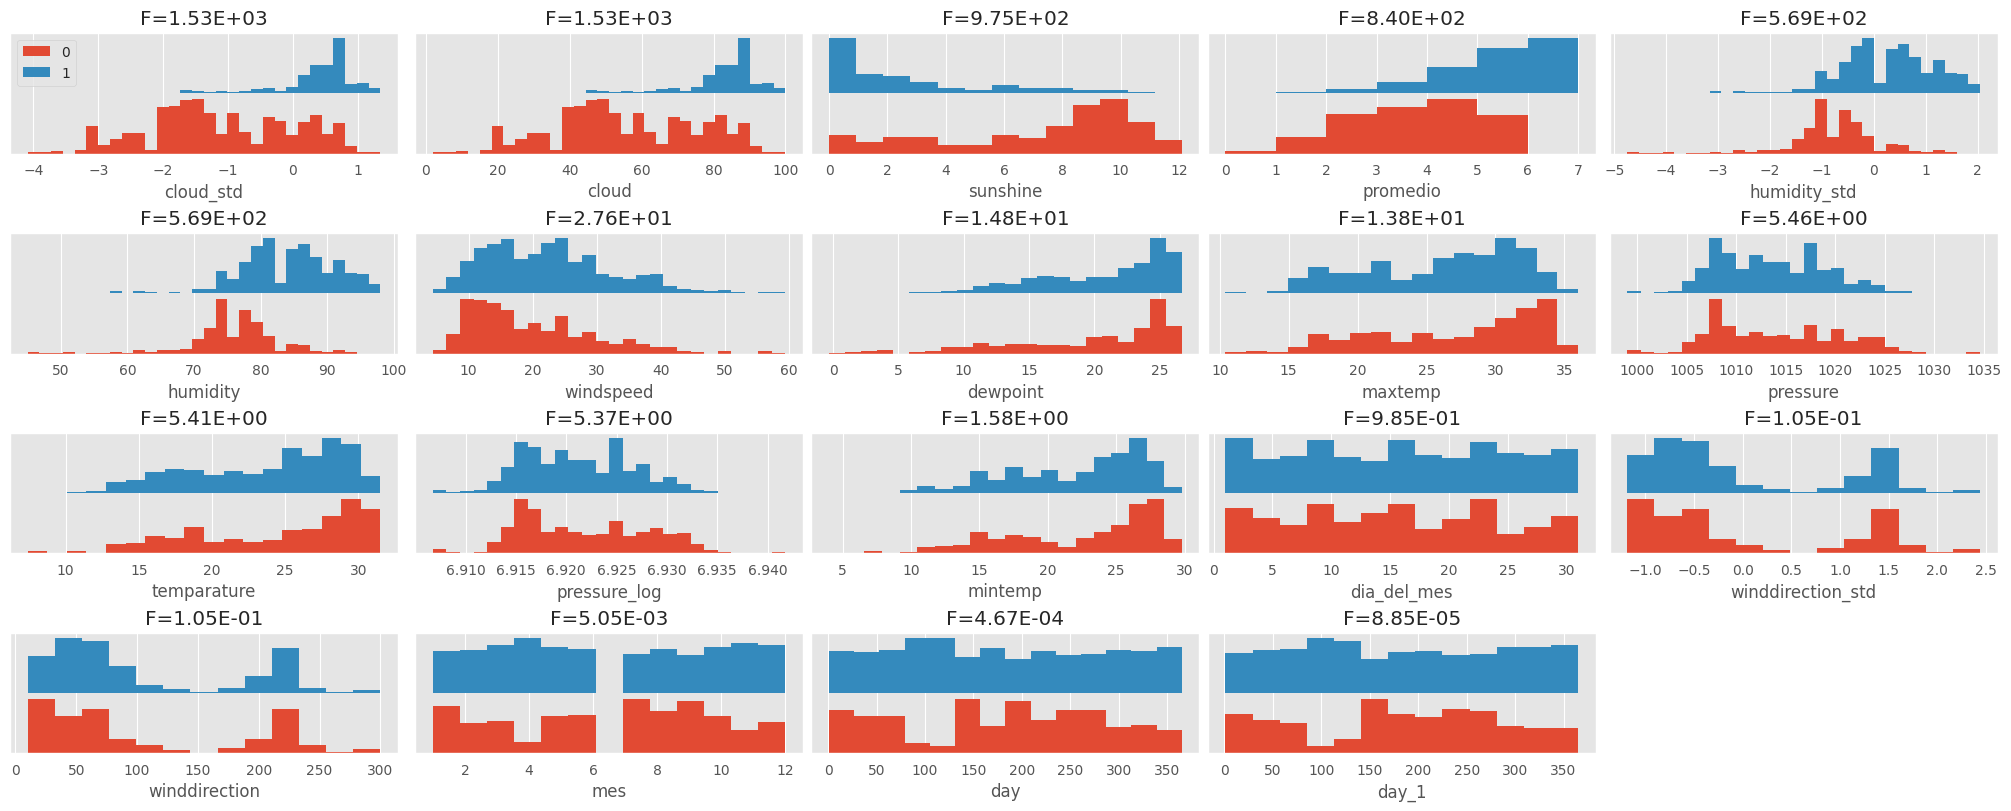

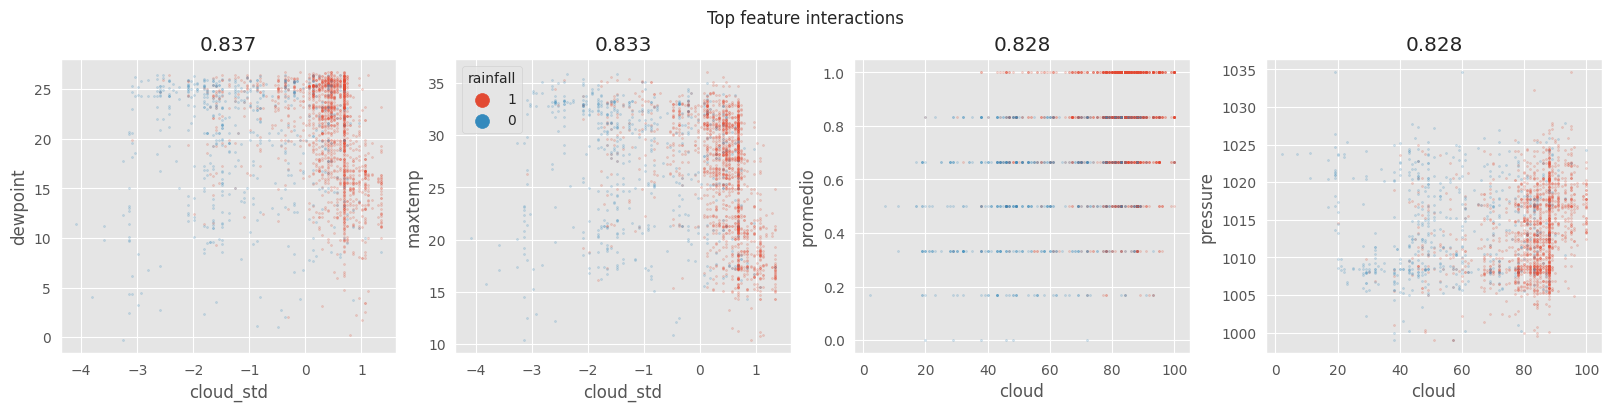

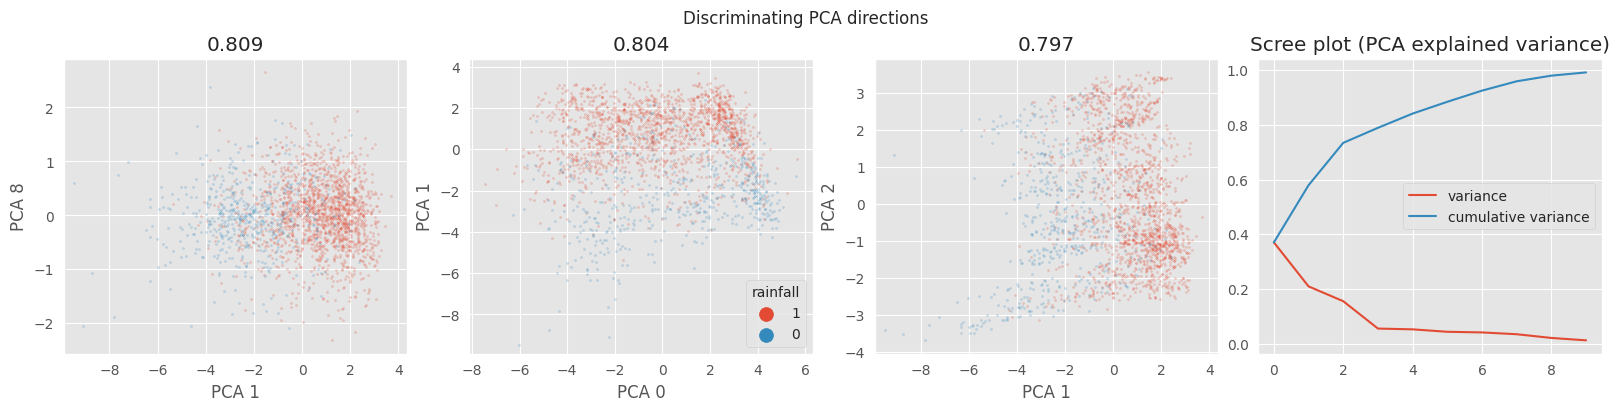

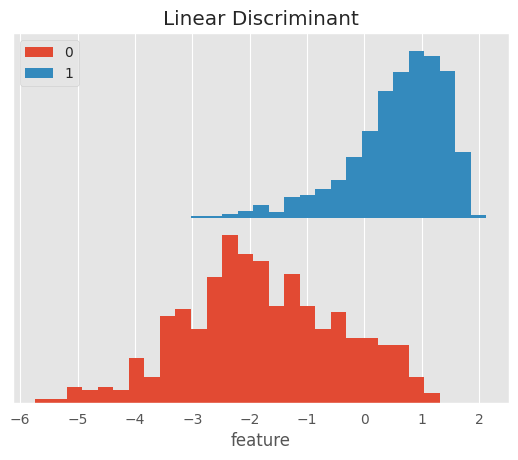

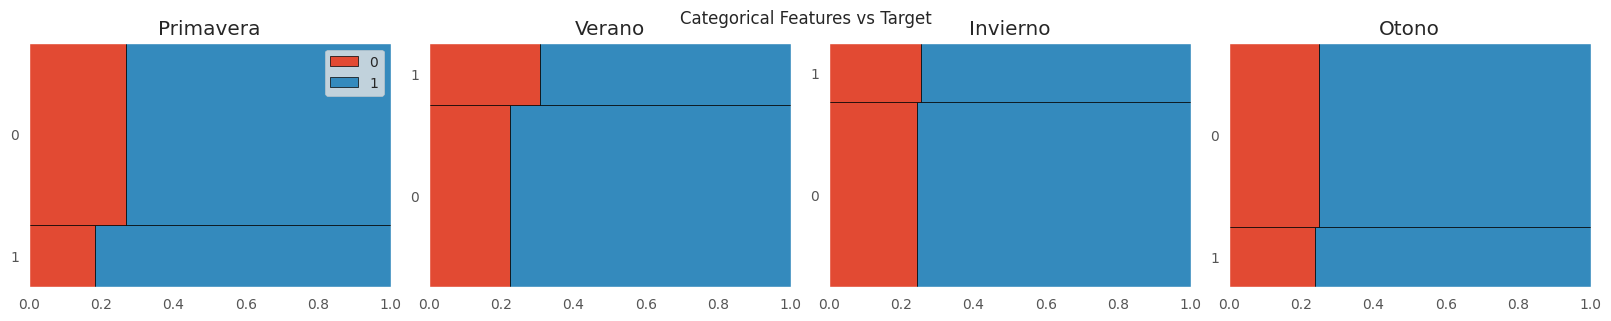

In [ ]:
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
dabl.plot(train_df_copy, target_col = 'rainfall')
# Acceder a la figura y los ejes
fig, ax = plt.gcf(), plt.gca()

# Eliminar la cuadrícula
ax.grid(False)

# Mostrar el gráfico
plt.show()

Target looks like classification
Linear Discriminant Analysis training set score: 0.818


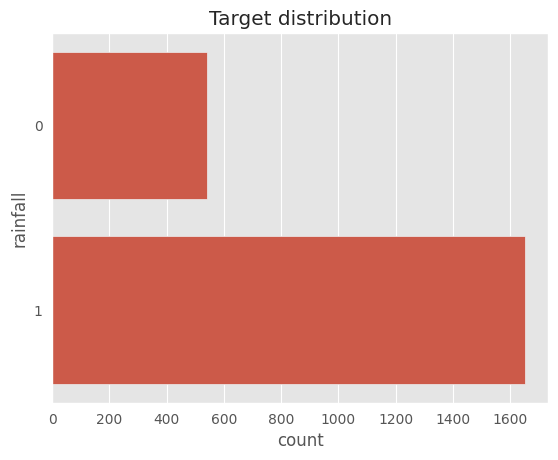

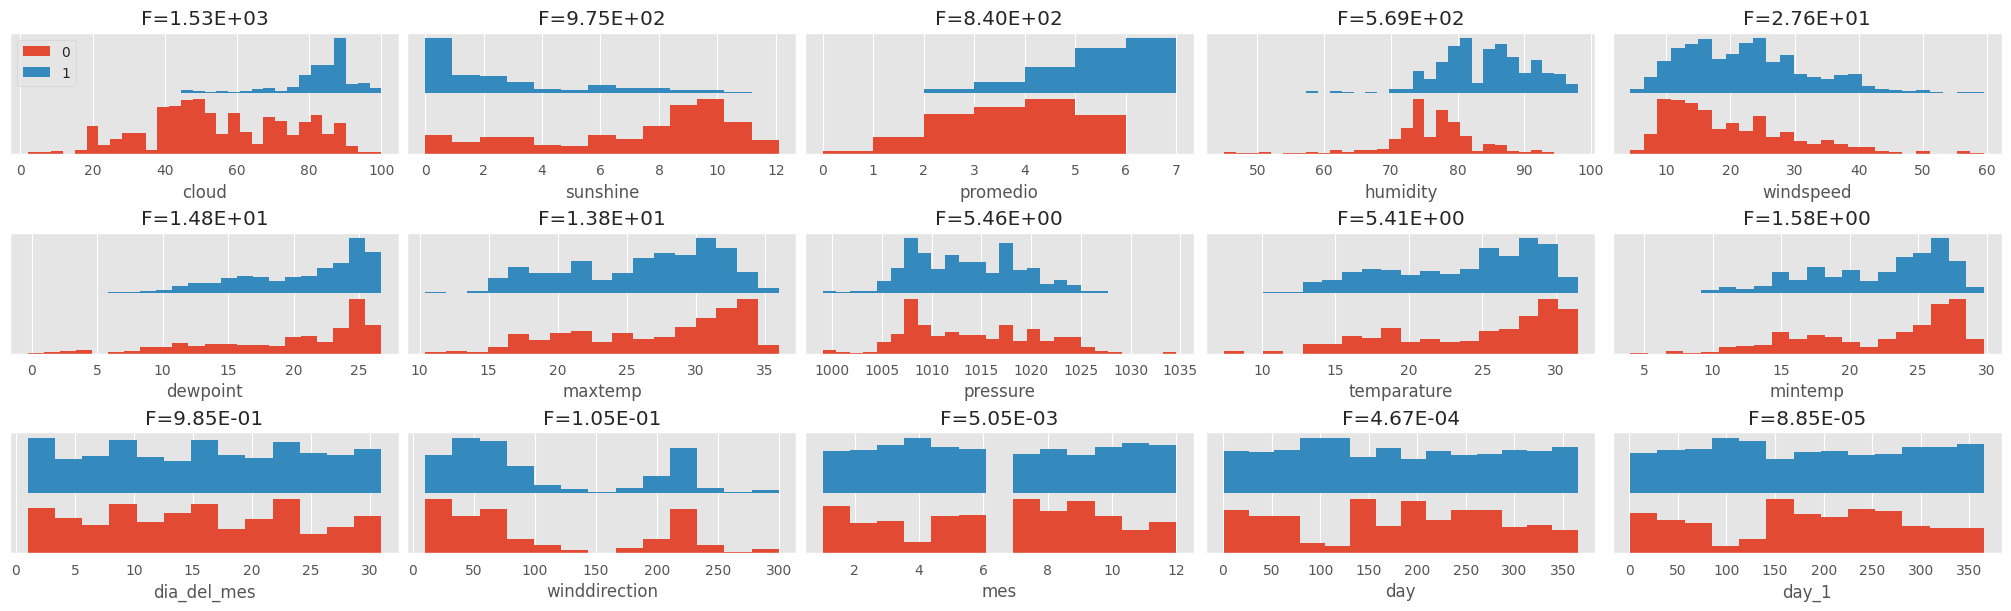

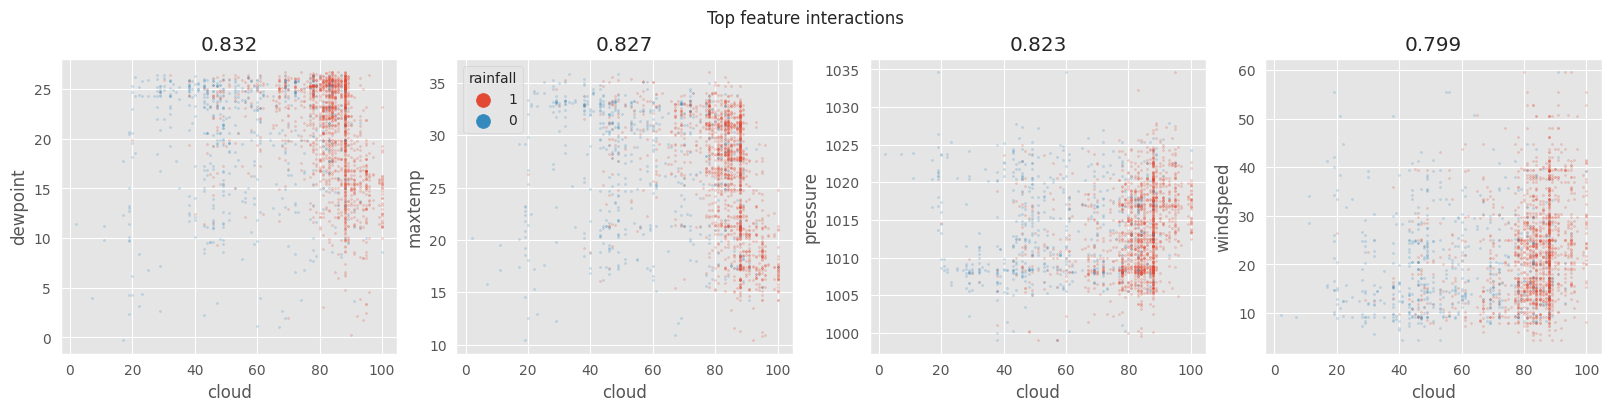

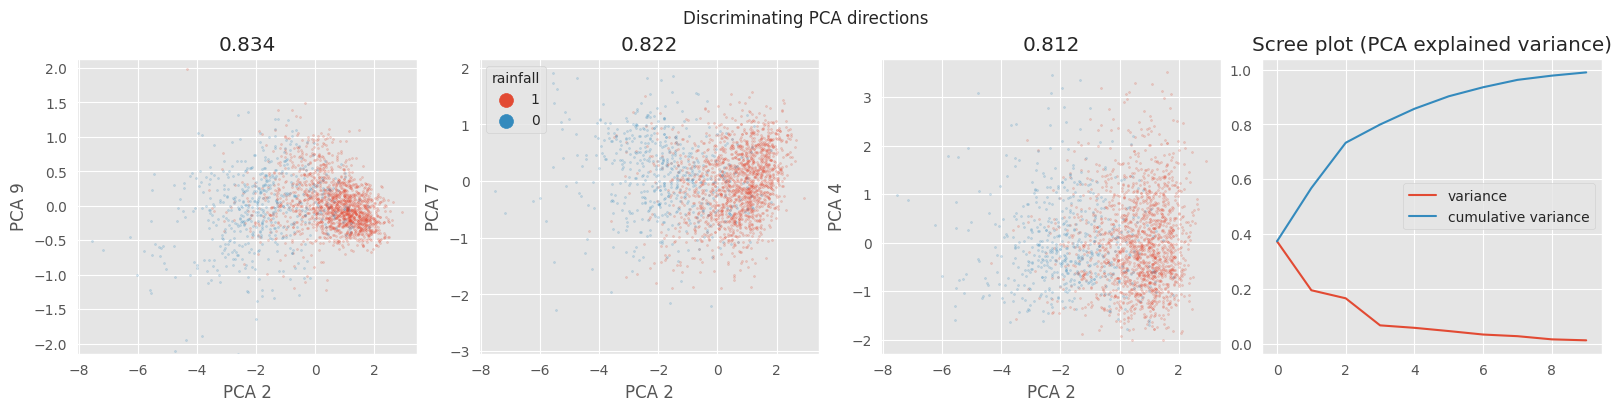

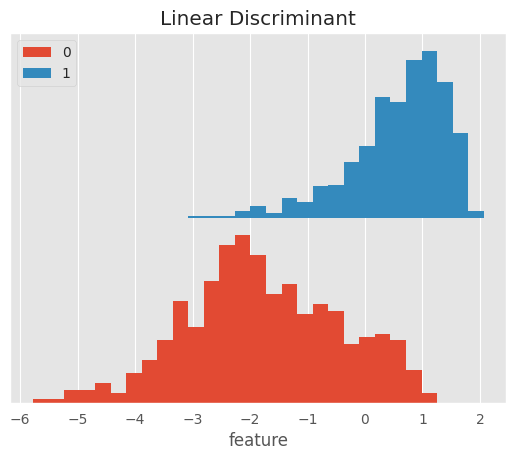

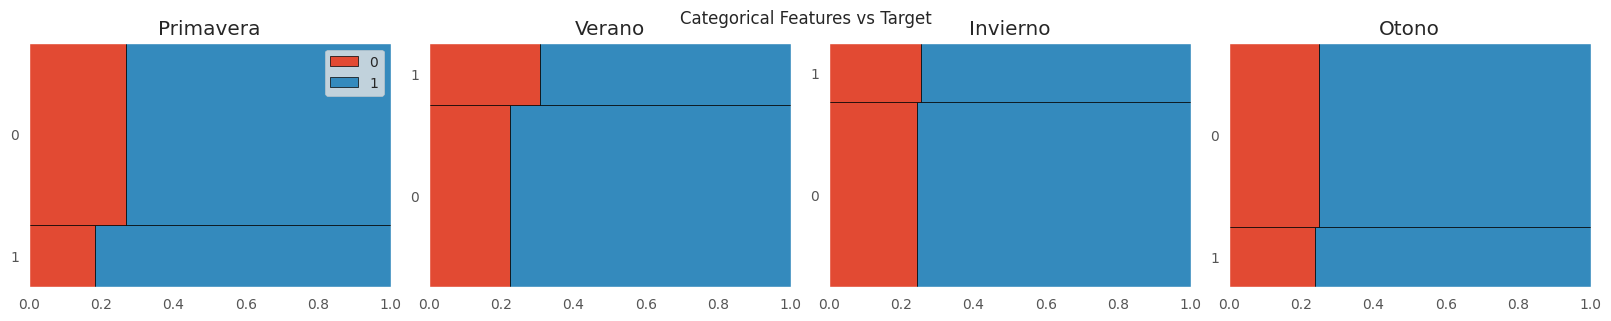

In [ ]:
import dabl
import warnings

plt.style.use('ggplot')
warnings.filterwarnings('ignore')
dabl.plot(train_df, target_col = 'rainfall')
# Acceder a la figura y los ejes
fig, ax = plt.gcf(), plt.gca()

# Eliminar la cuadrícula
ax.grid(False)

# Mostrar el gráfico
plt.show()

asi nos damos una idea de las caracteristicas que mas importan aunque suenen redundantes, las nubosidad, la temperatura, dewpoint, sunshine

In [ ]:
#procedemos a entrenar un modelo de xgboostclassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer

In [ ]:
train_df.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall', 'day_1', 'Primavera', 'Verano', 'Otono',
       'Invierno', 'mes', 'dia_del_mes', 'promedio'],
      dtype='object')

In [ ]:
X = train_df.drop(['id','rainfall','day','day_1','dia_del_mes','winddirection','pressure','temparature','mintemp','Otono','Primavera','Verano','windspeed','mes','maxtemp','dewpoint'],axis=1)
y = train_df['rainfall']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

In [ ]:
# Definir el modelo XGBoost Classifier
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc')  # Ajusta 'eval_metric' según sea necesario

# Definir la grilla de parámetros que deseas explorar
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01,.05, 0.1, 0.2],
    'max_depth': [3, 4, 5,6,7,8],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

In [ ]:
# Configurar la validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurar la métrica de evaluación (ROC AUC)
roc_auc = make_scorer(roc_auc_score)

In [ ]:
# Realizar la búsqueda de la grilla con validación cruzada
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring=roc_auc, cv=cv, verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Obtener los mejores parámetros y el mejor modelo
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print("Mejores Parámetros:", best_params)

Fitting 5 folds for each of 1536 candidates, totalling 7680 fits
Mejores Parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.9}


Mejores Parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}

In [ ]:
# Realizar predicciones en el conjunto de prueba
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Calcular el ROC AUC en el conjunto de prueba
test_roc_auc = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC en el Conjunto de Prueba:", test_roc_auc)

ROC AUC en el Conjunto de Prueba: 0.9168494152046783


In [ ]:
y_preds = best_model.predict(X_test)
test_roc_auc = roc_auc_score(y_test, y_preds)
print("ROC AUC en el Conjunto de Prueba:", test_roc_auc)

ROC AUC en el Conjunto de Prueba: 0.8286732456140351


In [ ]:
#editar el test_df para poder aplicar el modelo xgb
len(test_df)

730

In [ ]:
#crear una columna llamada day_1 del 1 al 365, 2 veces
day_1 = pd.DataFrame(columns=['day_1'])
for i in range(2):
  rango = np.arange(1,366)
  day_1 = pd.concat([day_1,pd.DataFrame(rango,columns=['day_1'])], ignore_index=True)
#pegar day_1 al train_df
test_df = pd.concat([test_df,day_1.reset_index(drop=True)],axis=1) # Reset index of day_1 before concatenating

In [ ]:
crear_columnas_estaciones(test_df,'day_1')

In [ ]:
crear_columnas_dia_mes(test_df,'day_1')

In [ ]:
#unir test_df y promedios
test_df = pd.merge(test_df,promedios,left_on='day_1',right_on='dia',how='left')

In [ ]:
test_df.drop('dia',axis=1,inplace=True)

In [ ]:
X_test = test_df.drop(['id','day','day_1','dia_del_mes','winddirection','pressure','temparature','mintemp','Otono','Primavera','Verano','windspeed','mes','maxtemp','dewpoint'],axis=1)

In [ ]:
y_preds = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

In [ ]:
sample_submission_df['rainfall'] = y_pred_proba
#guardar como csv
sample_submission_df.to_csv('sample_submission10.csv',index=False)

In [ ]:
len(sample_submission_df)

730

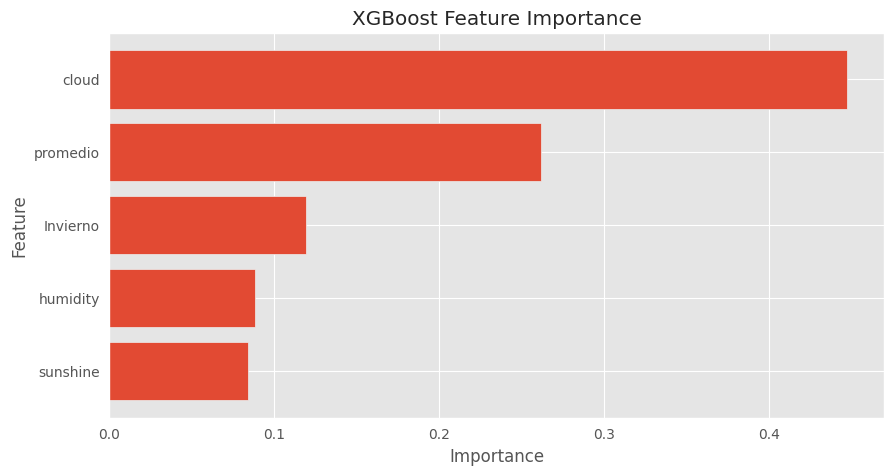

In [ ]:
FEATURES = X_test.columns.tolist()
feature_importance = best_model.feature_importances_
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()

PCA

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
X.columns

Index(['maxtemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'windspeed',
       'Primavera', 'Verano', 'Otono', 'Invierno', 'mes', 'dia_del_mes'],
      dtype='object')

In [ ]:
# Asumiendo que tu DataFrame se llama 'df' y la columna objetivo es 'lluvia'
X = train_df.drop(['id','rainfall','day','day_1','winddirection','pressure','temparature','mintemp','Otono','Primavera','Verano','windspeed','mes','maxtemp','dewpoint'],axis=1)
y = train_df['rainfall']  # Variable objetivo (lluvia: 1, no lluvia: 0)

# Escalar las características (importante para PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Crear un objeto PCA y ajustar el modelo a los datos escalados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
pca_df['lluvia'] = y.values  # Agregar la variable objetivo al DataFrame

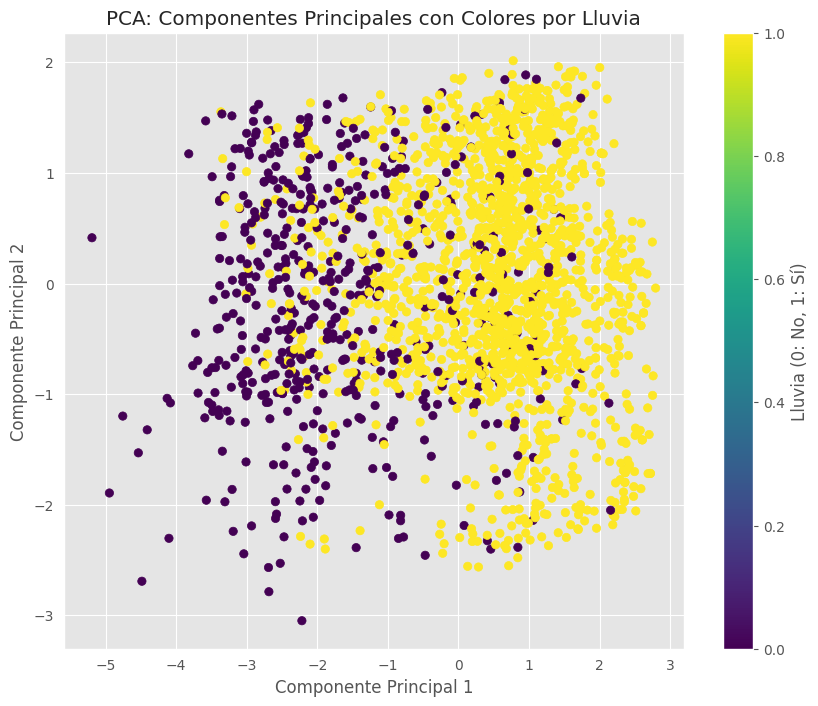

In [ ]:
# Crear la gráfica de dispersión
plt.figure(figsize=(10, 8))
plt.scatter(pca_df['Componente Principal 1'], pca_df['Componente Principal 2'], c=pca_df['lluvia'], cmap='viridis')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('PCA: Componentes Principales con Colores por Lluvia')
plt.colorbar(label='Lluvia (0: No, 1: Sí)')
plt.show()

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [ ]:
# Asumiendo que 'pca_df' es tu DataFrame con los componentes principales y 'lluvia'
X = pca_df[['Componente Principal 1', 'Componente Principal 2']]
y = pca_df['lluvia']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

In [ ]:
# Crear y entrenar el modelo QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

In [ ]:
# Obtener probabilidades predichas
y_pred_proba = qda.predict_proba(X_test)[:, 1]

# Obtener predicciones binarias
y_pred = qda.predict(X_test)

In [ ]:
# Calcular ROC AUC para probabilidades
roc_auc_proba = roc_auc_score(y_test, y_pred_proba)
print("ROC AUC (Probabilidades):", roc_auc_proba)

# Calcular ROC AUC para predicciones binarias
roc_auc_pred = roc_auc_score(y_test, y_pred)
print("ROC AUC (Predicciones Binarias):", roc_auc_pred)

ROC AUC (Probabilidades): 0.8762487816764132
ROC AUC (Predicciones Binarias): 0.809484649122807


In [ ]:
#ahora con el test_df
X_test = test_df.drop(['id','day','day_1','winddirection','pressure','temparature','mintemp','Otono','Primavera','Verano','windspeed','mes','maxtemp','dewpoint'],axis=1)
# Impute missing values using the mean
X_test = X_test.fillna(X_test.mean()) # Replace NaN with the mean of each column
X_scaled = scaler.fit_transform(X_test)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame con los componentes principales
pca_df_test = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
y_pred = qda.predict(pca_df_test)
y_pred_proba = qda.predict_proba(pca_df_test)[:, 1]

In [ ]:
sample_submission_df['rainfall'] = y_pred_proba
#guardar como csv
sample_submission_df.to_csv('sample_submission7.csv',index=False)